<a href="https://colab.research.google.com/github/dang710206/Baitap-AI-/blob/main/Bt4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Index(['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2',
       'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2',
       'geometry'],
      dtype='object')
       GID_2 GID_0  COUNTRY    GID_1   NAME_1 NL_NAME_1     NAME_2  VARNAME_2  \
0  VNM.1.1_1   VNM  Vietnam  VNM.1_1  AnGiang        NA      AnPhú      AnPhu   
1  VNM.1.3_1   VNM  Vietnam  VNM.1_1  AnGiang        NA    ChâuĐốc    ChauDoc   
2  VNM.1.4_1   VNM  Vietnam  VNM.1_1  AnGiang        NA    ChâuPhú    ChauPhu   
3  VNM.1.5_1   VNM  Vietnam  VNM.1_1  AnGiang        NA  ChâuThành  ChauThanh   
4  VNM.1.2_1   VNM  Vietnam  VNM.1_1  AnGiang        NA     ChợMới     ChoMoi   

  NL_NAME_2    TYPE_2 ENGTYPE_2 CC_2    HASC_2  \
0        NA     Huyện  District   NA  VN.TT.AL   
1        NA  Thànhphố      City   NA  VN.KG.AB   
2        NA     Huyện  District   NA  VN.HP.AD   
3        NA     Huyện  District   NA  VN.GL.AK   
4        NA     Huyện  District   NA  VN.BD.AL   

                  

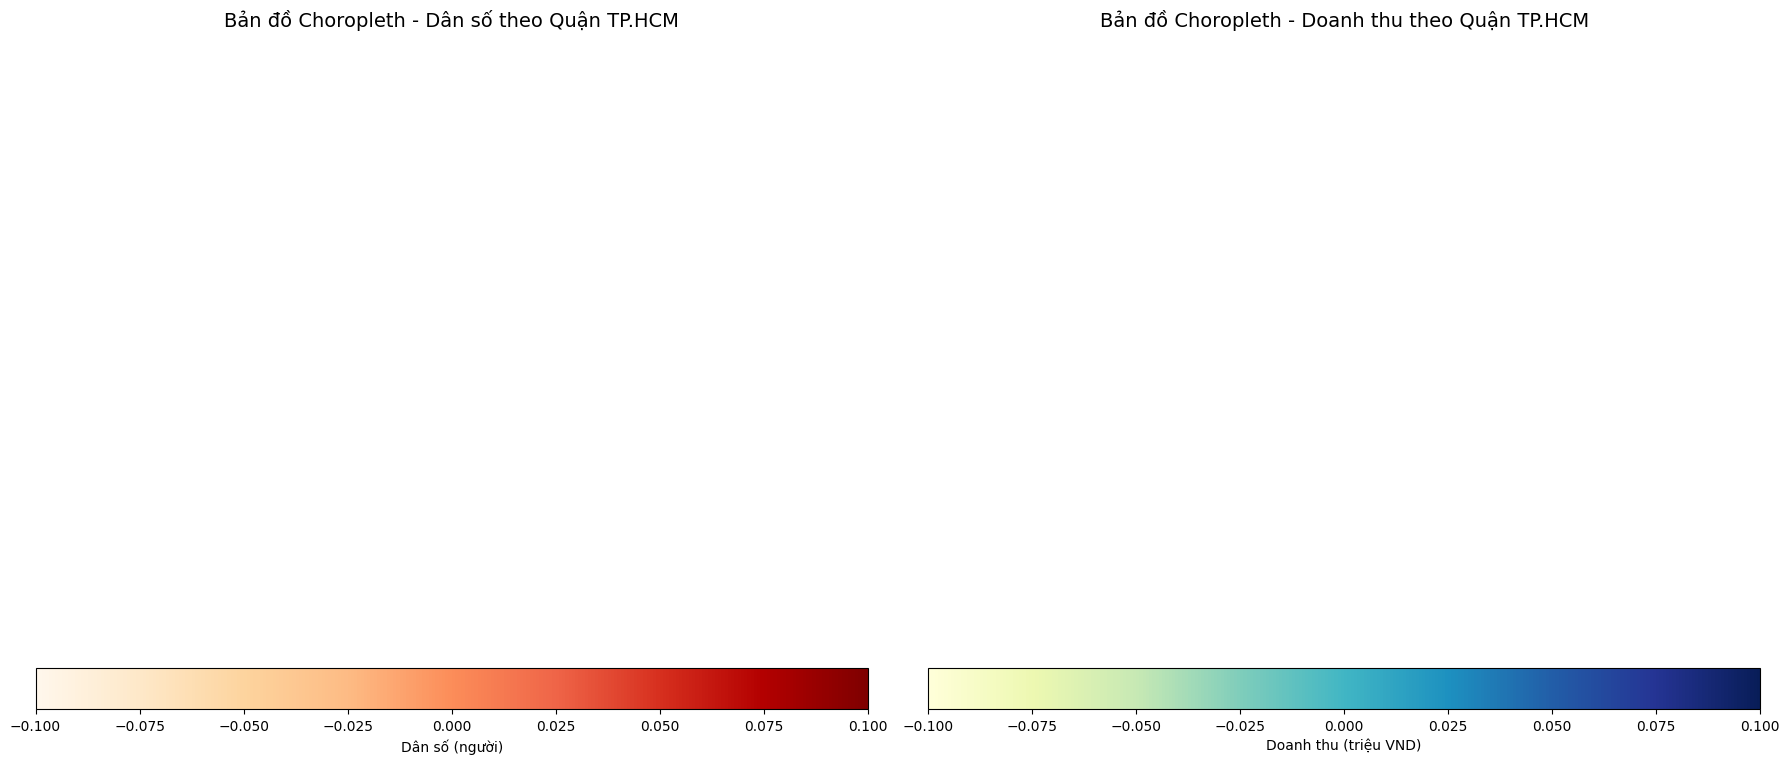

In [ ]:
#BT4
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

gdf = gpd.read_file('/content/gadm41_VNM_2.json')

# Kiểm tra cột tên quận
print(gdf.columns)
print(gdf.head())

np.random.seed(42)

# Danh sách một số quận phổ biến ở TP.HCM
districts = ['Quận 1', 'Quận 3', 'Quận 5', 'Quận 7', 'Quận 10', 'Bình Thạnh',
             'Thủ Đức', 'Tân Bình', 'Phú Nhuận', 'Gò Vấp', 'Bình Tân', 'Hóc Môn']

# Tạo dữ liệu
data = {
    'NAME_2': districts,
    'Dan_so': np.random.randint(150000, 600000, len(districts)),
    'Doanh_thu': np.random.randint(500, 5000, len(districts)) * 1000,   # đơn vị triệu VND
    'So_don_hang': np.random.randint(8000, 45000, len(districts))
}

df_data = pd.DataFrame(data)

# Merge theo tên quận (điều chỉnh tên cột nếu khác)
gdf = gdf.merge(df_data, left_on='NAME_2', right_on='NAME_2', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bản đồ theo Dân số
gdf.plot(column='Dan_so',
         cmap='OrRd',
         legend=True,
         legend_kwds={'label': "Dân số (người)", 'orientation': "horizontal"},
         ax=axes[0])
axes[0].set_title('Bản đồ Choropleth - Dân số theo Quận TP.HCM', fontsize=14)
axes[0].axis('off')

# Bản đồ theo Doanh thu
gdf.plot(column='Doanh_thu',
         cmap='YlGnBu',
         legend=True,
         legend_kwds={'label': "Doanh thu (triệu VND)", 'orientation': "horizontal"},
         ax=axes[1])
axes[1].set_title('Bản đồ Choropleth - Doanh thu theo Quận TP.HCM', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()
